# Lunar Orbit Geometry and Sky Coverage

Aaron Parsons

For a set of orbital configurations (altitude, orbit orientation, spin axis,
spin period, integration time) this notebook computes:

1. **Moon angular size** — half-angle and solid angle subtended by the Moon.
2. **Angular motion of Moon center** in the spacecraft body frame over one spin
   period and over one integration.
3. **Monthly sky-coverage fraction** — the fraction of time each galactic pixel
   is blocked by the Moon over one orbit (constant over a month for a fixed
   orbital plane), shown as a shaded Mollweide map.
4. **Sun and Earth trajectories** — where each body appears on the sky
   (galactic frame) over one month, overplotted on the coverage map.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import healpy
from astropy.time import Time
import astropy.units as u

from eigsep_sim.lunar_orbit import LunarOrbit, circular_orbital_period
from eigsep_sim.src import SourceCatalog
from eigsep_sim.const import R_MOON

%matplotlib inline

## Configuration

In [24]:
# Epoch for Sun/Earth ephemeris (start of the month).
OBS_EPOCH = Time('2028-06-01T00:00:00')
N_DAYS    = 30    # duration of the month [days]
N_TIME    = 3000   # time steps for Sun/Earth trajectory (~10 per day)

# HEALPix resolution for the coverage map.
NSIDE        = 32
NPIX         = healpy.nside2npix(NSIDE)
N_ORB_SAMP   = 512   # orbital phase samples for coverage map

# Orbital configurations to compare.
# Each dict specifies:
#   altitude      [m]       — orbital altitude above lunar surface
#   rot_orbit_vec (3,)      — orbit-plane normal in galactic frame
#   spin_vec      (3,)      — spacecraft spin axis in galactic frame
#   start_pos     (3,)      — initial orbital position direction (must be ⊥ rot_orbit_vec)
#   spin_period   [s]       — spin period (0 = no spin)
#   t_int         [s]       — integration time per sample
CONFIGS = [
    dict(
        label         = 'A',
        altitude      = 50e3,
        rot_orbit_vec = [0, 0, 1],   # orbit normal = galactic z
        spin_vec      = [0, 0, 1],   # spin about galactic z  →  spin ⊥ nadir
        start_pos     = [1, 0, 0],
        spin_period   = 60.0,        # 1 min
        t_int         = 1.0,         # 1 s
    ),
    dict(
        label         = 'B',
        altitude      = 100e3,
        rot_orbit_vec = [0, 0, 1],
        spin_vec      = [1, 0, 0],   # spin about galactic x  →  spin ∥ nadir at th=0
        start_pos     = [1, 0, 0],
        spin_period   = 60.0,
        t_int         = 1.0,
    ),
    dict(
        label         = 'C',
        altitude      = 500e3,
        rot_orbit_vec = [1, 0, 0],   # orbit normal = galactic x  →  orbit in y-z plane
        spin_vec      = [1, 0, 0],   # spin ∥ orbit normal  →  spin ⊥ nadir
        start_pos     = [0, 1, 0],   # must be ⊥ rot_orbit_vec
        spin_period   = 60.0,
        t_int         = 1.0,
    ),
]

## Moon geometry: angular size and nadir motion

In [25]:
def moon_angular_radius(altitude):
    """Half-angle subtended by Moon disk from orbital altitude [rad]."""
    return np.arcsin(R_MOON / (R_MOON + altitude))


def moon_solid_angle(altitude):
    """Solid angle subtended by Moon disk [sr]."""
    alpha = moon_angular_radius(altitude)
    return 2 * np.pi * (1 - np.cos(alpha))


def make_orbit(cfg):
    """Construct a LunarOrbit from a config dict."""
    return LunarOrbit(
        altitude      = cfg['altitude'],
        rot_orbit_vec = cfg['rot_orbit_vec'],
        rot_spin_vec  = cfg['spin_vec'],
        start_pos     = cfg.get('start_pos', [1, 0, 0]),
        spin_period   = cfg['spin_period'],
    )


def nadir_arc_body_frame(orbit, dt_s, n_steps=512, fix_orbit=False):
    """
    Arc length [rad] traced by the Moon-centre direction in the spacecraft
    body frame over *dt_s* seconds, starting from orbital phase 0.

    Parameters
    ----------
    fix_orbit : bool
        If True, hold orbital phase fixed at 0 and only advance the spin.
        This isolates the contribution of spin alone (useful for arc/spin).
        If False (default), both orbital motion and spin advance together
        (useful for arc/t_int where both contribute to beam smearing).
    """
    T_orb = orbit.orbital_period
    T_sp  = orbit.spin_period
    arc   = 0.0
    prev  = None
    for i in range(n_steps + 1):
        frac = i / n_steps
        th_o = 0.0 if fix_orbit else 2 * np.pi * (dt_s / T_orb) * frac
        th_s = 2 * np.pi * (dt_s / T_sp ) * frac if T_sp > 0 else 0.0
        orbit.set_phases(th_o, th_s)
        pos     = orbit.spacecraft_position()           # galactic frame, metres
        nadir_g = -pos / np.linalg.norm(pos)            # toward Moon centre
        nadir_b = orbit.rot_gal2top() @ nadir_g         # body frame
        if prev is not None:
            arc += np.arccos(np.clip(prev @ nadir_b, -1.0, 1.0))
        prev = nadir_b.copy()
    return arc

In [29]:
header = (
    f"{'Config':<10}  {'alt':>6}  {'α_moon':>8}  "
    f"{'frac sky':>9}  {'t_orb': >6} {'arc/spin':>10}  {'arc/t_int':>10}"
)
print(header)
print('-' * len(header))

for cfg in CONFIGS:
    orb      = make_orbit(cfg)
    alt      = cfg['altitude']
    alpha    = moon_angular_radius(alt)
    frac_sky = moon_solid_angle(alt) / (4 * np.pi)
    # orbital arc subtended during one spin period
    arc_spin = 360.0 * cfg['spin_period'] / orb.orbital_period
    # nadir arc in body frame during one integration (spin + orbital motion)
    arc_int  = nadir_arc_body_frame(orb, cfg['t_int'])
    print(
        f"{cfg['label']:<10}  {alt/1e3:>5.0f}k  "
        f"{np.rad2deg(alpha):>7.2f}°  "
        f"{frac_sky:>9.3f}  "
        f"{orb.orbital_period:>6.0f}  "
        f"{arc_spin:>9.2f}°  "
        f"{np.rad2deg(arc_int):>9.4f}°"
    )
print(f"\nColumns: altitude | moon half-angle | fraction of sky blocked "
      f"| orbital arc per spin period | nadir arc in body frame per integration")

Config         alt    α_moon   frac sky   t_orb   arc/spin   arc/t_int
----------------------------------------------------------------------
A              50k    76.42°      0.383    6780       3.19°     5.9469°
B             100k    71.01°      0.337    7066       3.06°     0.0510°
C             500k    50.94°      0.185    9495       2.27°     5.9621°

Columns: altitude | moon half-angle | fraction of sky blocked | orbital arc per spin period | nadir arc in body frame per integration


## Moon sky-coverage fraction (one orbit = monthly pattern)

For a fixed orbital plane the Moon occupies the same patch of sky with the
same duty cycle every orbit.  The monthly average coverage fraction therefore
equals the single-orbit average, computed by sampling `N_ORB_SAMP` equally
spaced orbital phases and accumulating the per-pixel Moon-disk mask.

In [17]:
coverage_maps = []
th_orbits = np.linspace(0, 2 * np.pi, N_ORB_SAMP, endpoint=False)

for cfg in CONFIGS:
    orb      = make_orbit(cfg)
    coverage = np.zeros(NPIX, dtype=float)
    for th in th_orbits:
        orb.set_phases(th)
        # above_horizon: True = sky visible, False = blocked by Moon
        coverage += ~orb.above_horizon(NSIDE)
    coverage_maps.append(coverage / N_ORB_SAMP)
    print(f"{cfg['label'][:60]}  →  mean coverage {coverage.mean()/N_ORB_SAMP:.3f}")

100 km, orbit in gal. x-y plane, spin || orbit normal (z)  →  mean coverage 0.382
100 km, orbit in gal. x-y plane, spin || gal. x  →  mean coverage 0.337
500 km, polar orbit (normal || gal. x), spin || orbit normal  →  mean coverage 0.185


## Sun and Earth trajectories over one month

Source positions are computed from the Moon's perspective via the
`SourceCatalog` ephemeris and converted to galactic unit vectors.
The Moon orbits Earth in ~27.3 days, so both Sun and Earth directions
sweep significant arcs over the 30-day window.

In [18]:
times_month = OBS_EPOCH + np.linspace(0, N_DAYS, N_TIME) * u.day

# Minimal frequency array — only positions are needed here.
catalog = SourceCatalog(NSIDE, np.array([100e6]), observer_body='moon')
catalog.add_sun()
catalog.add_earth()

sun_vecs   = []
earth_vecs = []

for t in times_month:
    catalog.update_positions(t)
    for src in catalog._ss_sources:
        if src.crd_gal is None:
            continue
        if src.name == 'sun':
            sun_vecs.append(src.crd_gal.copy())
        elif src.name == 'earth':
            earth_vecs.append(src.crd_gal.copy())

sun_vecs   = np.array(sun_vecs)    # (N_TIME, 3)
earth_vecs = np.array(earth_vecs)  # (N_TIME, 3)

# Total angular arc traced by each body over the month
def total_arc(vecs):
    dots = np.clip(np.einsum('ij,ij->i', vecs[:-1], vecs[1:]), -1, 1)
    return np.sum(np.arccos(dots))

print(f'Sun   arc over {N_DAYS} days: {np.rad2deg(total_arc(sun_vecs)):6.1f}°')
print(f'Earth arc over {N_DAYS} days: {np.rad2deg(total_arc(earth_vecs)):6.1f}°')

Sun   arc over 30 days:   28.7°
Earth arc over 30 days:  393.7°


## Plots: coverage maps and sky trajectories

Each row shows one orbital configuration.  The shading is the fraction of
time each galactic pixel is blocked by the Moon.  The Sun and Earth
trajectories are overplotted; the orbit-plane normal is marked with a star.

/tmp/ipykernel_84800/2730213271.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


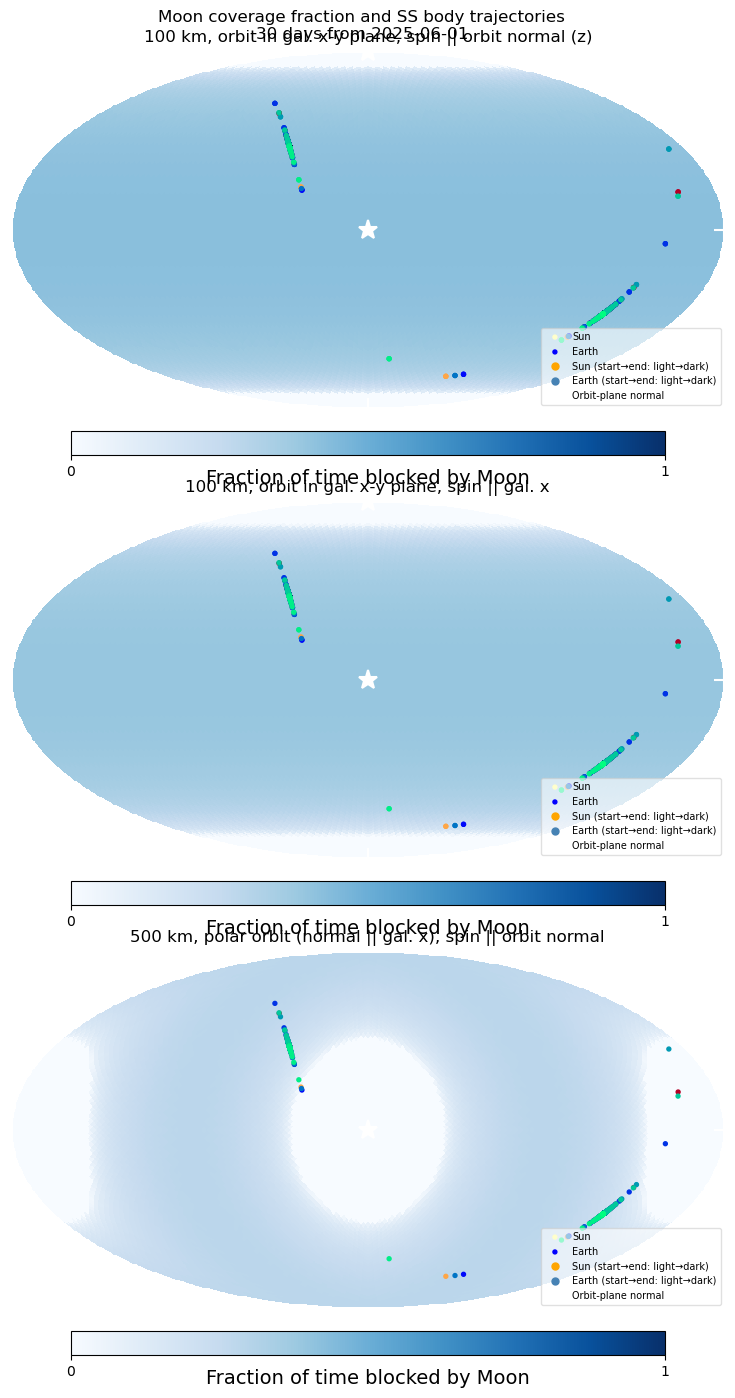

In [19]:
n_cfg   = len(CONFIGS)
fig     = plt.figure(figsize=(12, 4.5 * n_cfg))
fig_num = fig.number

# Galactic theta/phi for Sun and Earth tracks
t_sun,   p_sun   = healpy.vec2ang(sun_vecs.T)    # each shape (N_TIME,)
t_earth, p_earth = healpy.vec2ang(earth_vecs.T)

for ci, (cfg, cov) in enumerate(zip(CONFIGS, coverage_maps)):
    healpy.mollview(
        cov,
        fig   = fig_num,
        sub   = (n_cfg, 1, ci + 1),
        title = cfg['label'],
        cmap  = 'Blues',
        min   = 0,
        max   = 1,
        unit  = 'Fraction of time blocked by Moon',
    )

    # Sun trajectory (gold dots, darker start)
    healpy.projscatter(t_sun,   p_sun,
                       c=np.linspace(0, 1, len(t_sun)),
                       cmap='YlOrRd', s=8, zorder=3, label='Sun')

    # Earth trajectory (blue dots)
    healpy.projscatter(t_earth, p_earth,
                       c=np.linspace(0, 1, len(t_earth)),
                       cmap='winter', s=8, zorder=3, label='Earth')

    # Orbit-plane normal (both poles)
    orb_n = np.asarray(cfg['rot_orbit_vec'], dtype=float)
    orb_n /= np.linalg.norm(orb_n)
    for sign, mk in [(+1, 'w*'), (-1, 'w+')]:
        th_n, ph_n = healpy.vec2ang(sign * orb_n)
        healpy.projplot([th_n], [ph_n], mk, ms=14, mew=1.5)

    # Dummy legend artists
    ax = plt.gca()
    ax.plot([], [], 'o', color='orange',     ms=5, label='Sun (start→end: light→dark)')
    ax.plot([], [], 'o', color='steelblue',  ms=5, label='Earth (start→end: light→dark)')
    ax.plot([], [], 'w*', ms=10, label='Orbit-plane normal')
    ax.legend(loc='lower right', fontsize=7, framealpha=0.6)

plt.suptitle(
    f'Moon coverage fraction and SS body trajectories\n'
    f'{N_DAYS} days from {OBS_EPOCH.iso[:10]}',
    y=1.01, fontsize=12,
)
plt.tight_layout()
plt.show()

## Angular motion of the Moon vs. altitude and spin geometry

Quick parameter sweep: for a range of altitudes and spin configurations,
compare the nadir arc per spin period and per integration time.

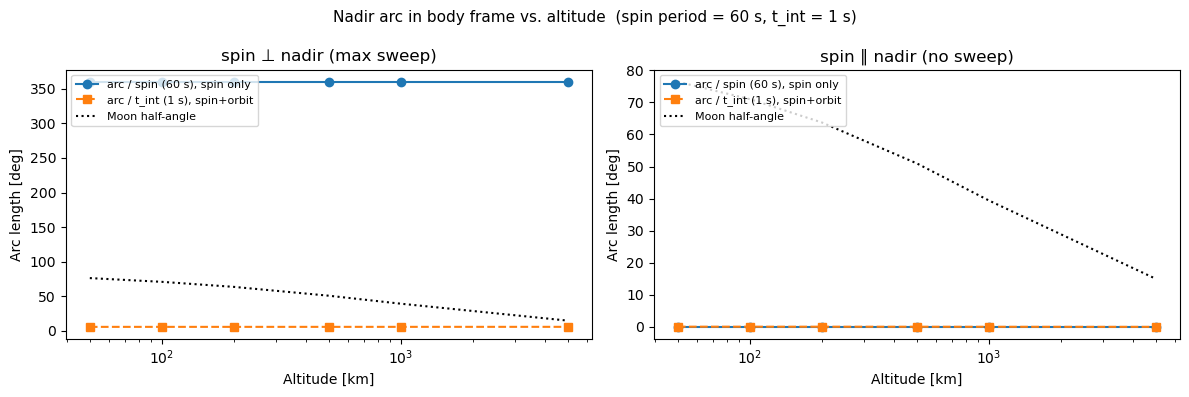

In [10]:
altitudes  = np.array([50, 100, 200, 500, 1000, 5000]) * 1e3   # metres
T_SPIN     = 60.0    # s
T_INT      = 1.0      # s

# Two representative spin geometries:
#   'perp'  — spin axis perpendicular to nadir at th_orbit=0 → maximum nadir sweep per spin
#   'para'  — spin axis parallel   to nadir at th_orbit=0 → no sweep from spin alone
spin_cases = {
    'spin ⊥ nadir (max sweep)': dict(rot_orbit_vec=[0,0,1], spin_vec=[0,0,1], start_pos=[1,0,0]),
    'spin ∥ nadir (no sweep)' : dict(rot_orbit_vec=[0,0,1], spin_vec=[1,0,0], start_pos=[1,0,0]),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, (label, geom) in zip(axes, spin_cases.items()):
    arcs_spin = []
    arcs_int  = []
    alpha_deg = []
    for alt in altitudes:
        orb = LunarOrbit(
            altitude      = alt,
            rot_orbit_vec = geom['rot_orbit_vec'],
            rot_spin_vec  = geom['spin_vec'],
            start_pos     = geom['start_pos'],
            spin_period   = T_SPIN,
        )
        arcs_spin.append(np.rad2deg(nadir_arc_body_frame(orb, T_SPIN, fix_orbit=True)))
        arcs_int.append( np.rad2deg(nadir_arc_body_frame(orb, T_INT)))
        alpha_deg.append(np.rad2deg(moon_angular_radius(alt)))

    alt_km = altitudes / 1e3
    ax.plot(alt_km, arcs_spin, 'C0o-',  label=f'arc / spin ({T_SPIN:.0f} s), spin only')
    ax.plot(alt_km, arcs_int,  'C1s--', label=f'arc / t_int ({T_INT:.0f} s), spin+orbit')
    ax.plot(alt_km, alpha_deg, 'k:',    lw=1.5, label='Moon half-angle')

    ax.set_xscale('log')
    ax.set_xlabel('Altitude [km]')
    ax.set_ylabel('Arc length [deg]')
    ax.set_title(label)
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle(
    'Nadir arc in body frame vs. altitude  '
    f'(spin period = {T_SPIN:.0f} s, t_int = {T_INT:.0f} s)',
    fontsize=11,
)
plt.tight_layout()
plt.show()